In [ ]:
# Install common machine learning libraries
# !pip install pandas numpy matplotlib seaborn scikit-learn
# !pip install cuml

# Carga librerias y preparacion datos

In [1]:
#Carga librerias para machine learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss,make_scorer


In [ ]:
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [2]:
#Carga archivo datos

df_partidos = pd.read_csv('/partidos_entrenamiento_modelo.csv')
df_partidos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241635 entries, 0 to 241634
Columns: 140 entries, Best_of_5 to age_diff_is_missing
dtypes: bool(1), float64(122), int64(12), object(5)
memory usage: 256.5+ MB


In [ ]:
df_prueba = df_partidos.query("player_A == 'carlos alcaraz'").tail(1)

#guardar archivo
df_prueba.to_csv('prueba.csv', index=False)


In [ ]:
#Selecciono los años más recientes
# df_partidos = df_partidos[df_partidos.Date > '2020-01-01']

In [3]:
#Duplicacion del dataset

import pandas as pd
import numpy as np

def crear_dataset_simetrico(df_original):
    print(f"⚖️  Simetrizando Dataset... (Filas originales: {len(df_original)})")

    # 1. Copia invertida del dataframe
    df_inverted = df_original.copy()

    # 2. Invertir el Target
    # Si en la original ganó A (1), en la invertida gana B (0 para playerA_won)
    if 'playerA_won' in df_inverted.columns:
        df_inverted['playerA_won'] = 1 - df_inverted['playerA_won']

    # 3. Detectar columnas para intercambiar
    cols = df_inverted.columns.tolist()
    rename_map = {}

    # Columnas que vamos a multiplicar por -1 (Diferencias)
    cols_to_negate = [c for c in cols if 'diff' in c.lower() or 'diferencia' in c.lower()]

    # Columnas que vamos a invertir 1/x (Ratios)
    cols_to_invert = [c for c in cols if 'ratio' in c.lower()]

    # 4. Lógica de Intercambio de Nombres (A <-> B)
    # Buscamos pares de columnas que sean iguales salvo por _A y _B
    # Ejemplo: 'EWM_A%_1' (que es de A) debería llamarse 'EWM_A%_1_TEMP'
    # Esta parte es delicada, lo haremos mapeando nombres.

    for col in cols:
        # Caso 1: Sufijos explícitos _A y _B (ej. rank_A, rank_B)
        if col.endswith('_A'):
            base = col[:-2]
            if f"{base}_B" in cols:
                rename_map[col] = f"{base}_B"
                rename_map[f"{base}_B"] = col

        # Caso 2: Prefijos player_A, player_B
        elif 'player_A' in col:
            new_col = col.replace('player_A', 'player_B')
            if new_col in cols:
                rename_map[col] = new_col
                rename_map[new_col] = col

        # Caso 3: Tus variables estadísticas específicas
        # Tienes columnas que se llaman igual para A y B?
        # En tu código anterior vi: 'playerA_A%', 'playerB_A%' ?
        # Si usaste groupby('player_A'), tus columnas estadísticas suelen ser 'EWM_A%_1'.
        # ¡OJO! Aquí está la clave.
        # Si tus columnas estadísticas NO tienen sufijo _A o _B explícito,
        # significa que solo tienes las stats de A.
        # EN ESE CASO, NECESITAS TENER LAS DE B TAMBIÉN EN LA MISMA FILA.

    # --- CORRECCIÓN IMPORTANTE ---
    # Para entrenar un modelo simétrico, cada fila DEBE tener los datos de A y de B.
    # Si tu df actual solo tiene 'EWM_Ace_A' y no 'EWM_Ace_B', no podemos invertirla.
    # Asumiré que tu df tiene variables diferenciales (diff_...) listas.

    # Si ya tienes las variables 'diff_', al invertir la fila:
    # diff_rank (A - B) pasa a ser (B - A), es decir, diff_rank * -1

    for col in cols_to_negate:
        df_inverted[col] = df_inverted[col] * -1

    for col in cols_to_invert:
        # Evitar división por cero
        df_inverted[col] = df_inverted[col].apply(lambda x: 1.0/x if x!=0 else 0)

    # 5. Intercambiar columnas "Crudas" si existen (rank_A, rank_B, ht_A, ht_B)
    # Usamos un rename temporal para no machacar datos
    temp_rename = {k: k+"_TEMP_SWAP" for k in rename_map.keys()}
    df_inverted = df_inverted.rename(columns=temp_rename)

    # Quitamos el sufijo temporal y asignamos el nombre contrario
    final_rename = {k+"_TEMP_SWAP": v for k, v in rename_map.items()}
    df_inverted = df_inverted.rename(columns=final_rename)

    # 6. Concatenar
    df_simetrico = pd.concat([df_original, df_inverted], ignore_index=True)

    # 7. Mezclar (Shuffle) para que el entrenamiento no sea A,A,A... luego B,B,B...
    df_simetrico = df_simetrico.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"✅ Dataset Simétrico Creado. Filas finales: {len(df_simetrico)}")
    print("   (El modelo ahora verá cada partido desde ambas perspectivas)")
    return df_simetrico

# --- USO ---
# Ejecuta esto JUSTO ANTES de tu código de entrenamiento (XGBoost/RandomForest)
df_training_final = crear_dataset_simetrico(df_partidos)
df_partidos = df_training_final.copy()
# Ahora entrena tus 5 modelos usando 'df_training_final'
# X = df_training_final[features]
# y = df_training_final['playerA_won']
# ... fit ...

⚖️  Simetrizando Dataset... (Filas originales: 241635)
✅ Dataset Simétrico Creado. Filas finales: 483270
   (El modelo ahora verá cada partido desde ambas perspectivas)


In [4]:
import pandas as pd
import numpy as np

print("--- AUDITORÍA DE SIMETRÍA ---")

def verificar_espejo(df_final, df_original_len):
    # 1. Chequeo de Cantidad
    filas_totales = len(df_final)
    esperadas = df_original_len * 2

    print(f"1. Chequeo de Dimensiones:")
    print(f"   Filas Originales: {df_original_len}")
    print(f"   Filas Finales:    {filas_totales}")

    if filas_totales == esperadas:
        print("   ✅ CORRECTO: El número de filas se ha duplicado exactamente.")
    else:
        print(f"   ⚠️ ALERTA: Las filas no coinciden (Diff: {filas_totales - esperadas}). Revisa si había duplicados previos.")

    # 2. Chequeo de Identidad (Buscar el espejo)
    print("\n2. Chequeo de Identidad (Espejo):")

    # Tomamos una muestra aleatoria del dataset (intentamos buscar una fila donde ganó A para ver si se invierte)
    try:
        # Buscamos un partido donde playerA haya ganado originalmente
        muestra = df_final[df_final['playerA_won'] == 1].sample(1).iloc[0]
        ganador_original = "A"
    except:
        # Si no hay (raro), cogemos cualquiera
        muestra = df_final.sample(1).iloc[0]
        ganador_original = "B"

    pA = muestra['player_A']
    pB = muestra['player_B']
    fecha = muestra['Date']
    target = muestra['playerA_won']

    print(f"   Fila Base Seleccionada:")
    print(f"     Fecha: {fecha} | {pA} vs {pB}")
    print(f"     Resultado: Ganó {'A' if target==1 else 'B'} ({target})")

    # BUSCAMOS SU ESPEJO
    # El espejo debe tener: Misma Fecha, A=pB, B=pA
    espejo = df_final[
        (df_final['Date'] == fecha) &
        (df_final['player_A'] == pB) &
        (df_final['player_B'] == pA)
    ]

    if len(espejo) == 0:
        print("   ❌ ERROR CRÍTICO: No se encontró la fila espejo invertida.")
        print("      (Puede pasar si la fecha o los nombres sufrieron cambios, o si el shuffle borró algo).")
        return

    row_espejo = espejo.iloc[0]
    target_espejo = row_espejo['playerA_won']

    print(f"   Fila Espejo Encontrada:")
    print(f"     Fecha: {row_espejo['Date']} | {row_espejo['player_A']} vs {row_espejo['player_B']}")
    print(f"     Resultado: Ganó {'A' if target_espejo==1 else 'B'} ({target_espejo})")

    # 3. Validaciones Lógicas
    print("\n3. Validaciones Matemáticas:")
    errores = 0

    # A) Target Invertido
    if target == 1 - target_espejo:
        print("   ✅ Target: Invertido correctamente (1 -> 0 ó 0 -> 1).")
    else:
        print(f"   ❌ ERROR Target: No se invirtió ({target} vs {target_espejo}).")
        errores += 1

    # B) Variables Diff (Deben cambiar de signo)
    # Buscamos columnas 'diff' para testear
    cols_diff = [c for c in df_final.columns if 'diff' in c.lower()]
    if cols_diff:
        col_test = cols_diff[0] # Cogemos la primera que encontremos
        val_orig = muestra[col_test]
        val_espejo = row_espejo[col_test]

        # Tolerancia pequeña para floats
        if abs(val_orig + val_espejo) < 0.0001:
             print(f"   ✅ Diff ({col_test}): {val_orig:.4f} -> {val_espejo:.4f} (Signo cambiado).")
        else:
             print(f"   ❌ ERROR Diff ({col_test}): {val_orig} vs {val_espejo} (No suman 0).")
             errores += 1
    else:
        print("   ⚠️ No se encontraron columnas 'diff' para verificar.")

    # C) Variables Ratio (Deben ser inversas 1/x)
    cols_ratio = [c for c in df_final.columns if 'ratio' in c.lower()]
    if cols_ratio:
        col_test = cols_ratio[0]
        val_orig = muestra[col_test]
        val_espejo = row_espejo[col_test]

        if val_orig != 0 and abs((val_orig * val_espejo) - 1.0) < 0.01:
            print(f"   ✅ Ratio ({col_test}): {val_orig:.4f} * {val_espejo:.4f} ≈ 1.")
        elif val_orig == 0 and val_espejo == 0:
            print(f"   ✅ Ratio ({col_test}): Ambos son 0 (correcto).")
        else:
            # A veces los ratios dan problemas si son 1.0 exactos
            if val_orig == 1.0 and val_espejo == 1.0:
                print(f"   ✅ Ratio ({col_test}): Neutro (1.0 -> 1.0).")
            else:
                print(f"   ❌ ERROR Ratio ({col_test}): {val_orig} vs {val_espejo}.")
                errores += 1

    if errores == 0:
        print("\n🎉 CONCLUSIÓN: La simetrización es PERFECTA.")
    else:
        print(f"\n⚠️ CONCLUSIÓN: Se encontraron {errores} errores. Revisa el código.")

# --- EJECUTAR ---
# Calculamos la longitud original dividiendo por 2 (asumiendo que ya ejecutaste la duplicación)
# Si df_partidos ya es el duplicado:
len_orig_estimada = int(len(df_partidos) / 2)
verificar_espejo(df_partidos, len_orig_estimada)

--- AUDITORÍA DE SIMETRÍA ---
1. Chequeo de Dimensiones:
   Filas Originales: 241635
   Filas Finales:    483270
   ✅ CORRECTO: El número de filas se ha duplicado exactamente.

2. Chequeo de Identidad (Espejo):
   Fila Base Seleccionada:
     Fecha: 2023-06-12 | tallon griekspoor vs alex de minaur
     Resultado: Ganó A (1)
   Fila Espejo Encontrada:
     Fecha: 2023-06-12 | alex de minaur vs tallon griekspoor
     Resultado: Ganó B (0)

3. Validaciones Matemáticas:
   ✅ Target: Invertido correctamente (1 -> 0 ó 0 -> 1).
   ✅ Diff (age_diff): 2.6000 -> -2.6000 (Signo cambiado).
   ✅ Ratio (elo_ratio_surface): 0.9856 * 1.0146 ≈ 1.

🎉 CONCLUSIÓN: La simetrización es PERFECTA.


In [ ]:
# Entrenamiento con XGboost, se comprueba la ventana de tiempo ideal para el modelo
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

print("--- BENCHMARK MAESTRO: SELECCIÓN POR BRIER SCORE (VALIDACIÓN ESTACIONAL) ---")

# 1. PREPARACIÓN DE DATOS (Full Features + Log Rank)
df_modelo = df_partidos[
    (df_partidos['Tier_Numeric'] < 2)
].copy()


# Limpieza (Solo quitamos Fugas e IDs, MANTENEMOS todo lo demás, incluso baja varianza)
cols_fuga_ids = [
    'indice', 'Date', 'Tournament', 'player_A', 'player_B', 'Score',
    'playerA_won', 'Total_juegos', 'Numero_sets', 'duracion_min', 'Rd_Ordinal',
    'Diferencia_minutos_acumulados', 'Diferencia_partidos_torneo'
]

X = df_modelo.drop(columns=cols_fuga_ids, errors='ignore')
y = df_modelo['playerA_won']
fechas = pd.to_datetime(df_modelo['Date'])

# Dataset Final Test (2025) - El examen final
mask_2025 = fechas >= '2025-01-01'
X_2025 = X[mask_2025]
y_2025 = y[mask_2025]

print(f"Variables totales (incluyendo Log-Rank): {X.shape[1]}")

# 2. CONFIGURACIÓN
ventanas_inicio = [2002, 2010, 2015, 2018, 2022]
resultados = []

# Grilla amplia de parámetros
param_dist = {
    'n_estimators': [500, 800, 1000, 1500],
    'learning_rate': [0.005, 0.01, 0.02, 0.05],
    'max_depth': [1, 2, 3, 4, 5, 6],
    'min_child_weight': [3, 5, 7, 10],
    'gamma': [0.1, 0.3, 0.5],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

# Métricas: Optimizamos LogLoss, pero elegimos por Brier
metrics = {
    'LogLoss': 'neg_log_loss',
    'Brier': 'neg_brier_score'
}

print(f"{'VENTANA':<8} | {'TRAIN':<6} | {'VAL 24 BRIER':<12} | {'TEST 25 BRIER':<13} | {'TEST 25 ACC':<10}")
print("-" * 75)

for start_year in ventanas_inicio:
    # A. FILTROS TEMPORALES (Anti-Covid + Validación Estacional)

    mask_tuning = (
        (fechas >= f'{start_year}-01-01') &
        (fechas < '2025-01-01') &
        ~((fechas >= '2020-01-01') & (fechas < '2022-01-01'))
    )

    X_loop = X[mask_tuning].reset_index(drop=True)
    y_loop = y[mask_tuning].reset_index(drop=True)
    fechas_loop = fechas[mask_tuning].reset_index(drop=True)

    # --- B. PREDEFINED SPLIT (LA CLAVE DE LA VALIDACIÓN TEMPORAL) ---
    # Creamos una lista que le dice a GridSearchCV qué hacer con cada fila:
    # -1: "Esta fila es para ENTRENAR" (Años < 2024)
    #  0: "Esta fila es para VALIDAR" (Año 2024)
    # Esto garantiza que NO hay mezcla aleatoria. El futuro nunca predice el pasado.

    test_fold = [-1 if f.year < 2024 else 0 for f in fechas_loop]
    ps = PredefinedSplit(test_fold)

    # --- C. RANDOM SEARCH ---
    xgb_search = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42
    )

    rs = RandomizedSearchCV(
        estimator=xgb_search,
        param_distributions=param_dist,
        n_iter=30,               # 30 iteraciones
        scoring=metrics,         # Calculamos ambas métricas
        refit='Brier',           # <--- ELEGIMOS AL GANADOR POR SU CALIBRACIÓN (Brier)
        cv=ps,                   # <--- Usamos la división temporal manual
        verbose=0,
        n_jobs=-1,
        random_state=42
    )

    rs.fit(X_loop, y_loop)
    best_model = rs.best_estimator_

    # --- D. EVALUACIÓN EN TEST 2025 ---
    # Métrica de Validación (2024) del mejor modelo
    best_val_brier = -rs.best_score_

    # Métricas en Test (2025)
    probs_2025 = best_model.predict_proba(X_2025)[:, 1]
    preds_2025 = best_model.predict(X_2025)

    brier_25 = brier_score_loss(y_2025, probs_2025)
    acc_25 = accuracy_score(y_2025, preds_2025)
    ll_25 = log_loss(y_2025, probs_2025)

    print(f"{start_year:<8} | {test_fold.count(-1):<6} | {best_val_brier:.5f}      | {brier_25:.5f}       | {acc_25*100:.2f}%")

    resultados.append({
        'Ventana_Inicio': start_year,
        'Train_Size': test_fold.count(-1),
        'Val_2024_Brier': best_val_brier,
        'Test_2025_Brier': brier_25,
        'Test_2025_LogLoss': ll_25,
        'Test_2025_Acc': acc_25,
        'Best_Params': rs.best_params_
    })

# --- RESUMEN FINAL ---
df_res = pd.DataFrame(resultados).sort_values(by='Test_2025_Brier', ascending=True) # Menor Brier es mejor

print("\n" + "="*75)
print("🏆 PODIO FINAL (Ordenado por Calibración/Brier en 2025)")
print("="*75)
print(df_res[['Ventana_Inicio', 'Train_Size', 'Test_2025_Brier', 'Test_2025_Acc']])

ganador = df_res.iloc[0]
print(f"\n✅ VENTANA GANADORA: {ganador['Ventana_Inicio']}")
print(f"   Brier Score: {ganador['Test_2025_Brier']:.5f}")
print(f"   Accuracy:    {ganador['Test_2025_Acc']*100:.2f}%")
print(f"   Parámetros clave: {ganador['Best_Params']}")

--- BENCHMARK MAESTRO: SELECCIÓN POR BRIER SCORE (VALIDACIÓN ESTACIONAL) ---
Variables totales (incluyendo Log-Rank): 127
VENTANA  | TRAIN  | VAL 24 BRIER | TEST 25 BRIER | TEST 25 ACC
---------------------------------------------------------------------------
2002     | 245510 | 0.21121      | 0.22936       | 63.11%
2010     | 164370 | 0.21076      | 0.24043       | 61.89%
2015     | 114914 | 0.21165      | 0.23547       | 62.30%
2018     | 70316  | 0.21244      | 0.23702       | 61.41%
2022     | 36922  | 0.21345      | 0.23200       | 61.89%

🏆 PODIO FINAL (Ordenado por Calibración/Brier en 2025)
   Ventana_Inicio  Train_Size  Test_2025_Brier  Test_2025_Acc
0            2002      245510         0.229362       0.631100
4            2022       36922         0.232003       0.618944
2            2015      114914         0.235471       0.622967
3            2018       70316         0.237016       0.614133
1            2010      164370         0.240435       0.618856

✅ VENTANA GANADORA: 

In [ ]:
#Desempate entre 2022 y 2002
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

print("--- LA GRAN FINAL: 2015 vs 2018 (GRID SEARCH EXHAUSTIVO) ---")

# 1. PREPARACIÓN DE DATOS
df_modelo = df_partidos[
    (df_partidos['Tier_Numeric'] < 2)
].copy()

# Limpieza de columnas (Fugas + IDs).
# Mantenemos TODO lo demás (incluyendo tus log_rank pre-calculados y las de baja varianza)
cols_fuga_ids = [
    'indice', 'Date', 'Tournament', 'player_A', 'player_B', 'Score',
    'playerA_won', 'Total_juegos', 'Numero_sets', 'duracion_min', 'Rd_Ordinal',
    'Diferencia_minutos_acumulados', 'Diferencia_partidos_torneo'
]

X = df_modelo.drop(columns=cols_fuga_ids, errors='ignore')
y = df_modelo['playerA_won']
fechas = pd.to_datetime(df_modelo['Date'])

# Dataset Test 2025 (El Juez Final)
mask_2025 = fechas >= '2025-01-01'
X_2025 = X[mask_2025]
y_2025 = y[mask_2025]

print(f"Total de variables: {X.shape[1]}")

# 2. LOS FINALISTAS
ventanas_finalistas = [2002, 2022]

# 3. GRILLA EXHAUSTIVA
# 144 combinaciones por ventana. Cubre el espectro donde sabemos que funciona bien.
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.02, 0.03],
    'n_estimators': [800, 1200],
    'min_child_weight': [3, 5],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

resultados = []

print(f"{'VENTANA':<8} | {'TRAIN':<6} | {'VAL 24 BRIER':<12} | {'TEST 25 BRIER':<13} | {'TEST 25 ACC':<10}")
print("-" * 75)

for start_year in ventanas_finalistas:
    # A. PREPARACIÓN DATOS (Train < 2024, Val = 2024) - Anti-Covid
    mask_tuning = (
        (fechas >= f'{start_year}-01-01') &
        (fechas < '2025-01-01') &
        ~((fechas >= '2020-01-01') & (fechas < '2022-01-01'))
    )

    X_loop = X[mask_tuning].reset_index(drop=True)
    y_loop = y[mask_tuning].reset_index(drop=True)
    fechas_loop = fechas[mask_tuning].reset_index(drop=True)

    # Predefined Split: -1 (Train), 0 (Validation 2024)
    test_fold = [-1 if f.year < 2024 else 0 for f in fechas_loop]
    ps = PredefinedSplit(test_fold)

    # B. GRID SEARCH (Optimizando Brier Score)
    xgb_base = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42
    )

    grid = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        scoring='neg_brier_score', # <--- Objetivo: Calibración perfecta
        cv=ps,
        verbose=0,
        n_jobs=-1
    )

    grid.fit(X_loop, y_loop)
    best_model = grid.best_estimator_

    # C. EVALUACIÓN 2025
    # Brier en Validación (2024)
    best_val_brier = -grid.best_score_

    # Métricas en Test (2025)
    probs_2025 = best_model.predict_proba(X_2025)[:, 1]
    preds_2025 = best_model.predict(X_2025)

    brier_25 = brier_score_loss(y_2025, probs_2025)
    acc_25 = accuracy_score(y_2025, preds_2025)

    print(f"{start_year:<8} | {test_fold.count(-1):<6} | {best_val_brier:.5f}      | {brier_25:.5f}       | {acc_25*100:.2f}%")

    resultados.append({
        'Inicio': start_year,
        'Brier_2025': brier_25,
        'Acc_2025': acc_25,
        'Best_Params': grid.best_params_
    })

# --- VEREDICTO ---
df_res = pd.DataFrame(resultados).sort_values(by='Brier_2025', ascending=True) # Menor es mejor
print("\n" + "="*75)
print("🏆 CAMPEÓN DEFINITIVO (Menor Brier = Mejor Calibración)")
print("="*75)
print(df_res)

winner = df_res.iloc[0]
print(f"\n✅ La ventana ganadora es {winner['Inicio']}")
print(f"   Mejores Params: {winner['Best_Params']}")

--- LA GRAN FINAL: 2015 vs 2018 (GRID SEARCH EXHAUSTIVO) ---
Total de variables: 127
VENTANA  | TRAIN  | VAL 24 BRIER | TEST 25 BRIER | TEST 25 ACC
---------------------------------------------------------------------------


C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


2002     | 245510 | 0.21094      | 0.23500       | 62.50%
2022     | 36922  | 0.21305      | 0.23640       | 61.75%

🏆 CAMPEÓN DEFINITIVO (Menor Brier = Mejor Calibración)
   Inicio  Brier_2025  Acc_2025  \
0    2002    0.234995  0.624978   
1    2022    0.236405  0.617544   

                                         Best_Params  
0  {'colsample_bytree': 0.8, 'learning_rate': 0.0...  
1  {'colsample_bytree': 0.8, 'learning_rate': 0.0...  

✅ La ventana ganadora es 2002
   Mejores Params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 1200, 'subsample': 0.8}


In [ ]:
#Entrenamiento modelo con la ventana ideal

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss
import time

print("--- FASE FINAL: TUNING MASIVO (200 ITERACIONES) ---")
start_time = time.time()

# 1. PREPARACIÓN DE DATOS (Ventana 2002)
df_modelo = df_partidos[
    (df_partidos['Tier_Numeric'] < 2) &
    (pd.to_datetime(df_partidos['Date']) >= '2002-01-01')
].copy()


# Limpieza Básica
cols_borrar = [
    'indice', 'Date', 'Tournament', 'player_A', 'player_B', 'Score',
    'playerA_won', 'Total_juegos', 'Numero_sets', 'duracion_min', 'Rd_Ordinal',
    'Diferencia_minutos_acumulados', 'Diferencia_partidos_torneo'
]

X = df_modelo.drop(columns=cols_borrar, errors='ignore')
y = df_modelo['playerA_won']
fechas = pd.to_datetime(df_modelo['Date'])

# --- DEFINICIÓN DE SETS (Anti-Covid + Validación Estacional) ---
mask_train = (fechas < '2024-01-01') & ~((fechas >= '2020-01-01') & (fechas < '2022-01-01'))
mask_val = (fechas >= '2024-01-01') & (fechas < '2025-01-01')
mask_test = fechas >= '2025-01-01'

X_train, y_train = X[mask_train], y[mask_train]
X_val, y_val = X[mask_val], y[mask_val]
X_test, y_test = X[mask_test], y[mask_test]

print(f"Datos Listos. Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ==============================================================================
# PASO 1: SELECCIÓN DE VARIABLES (FEATURE SELECTION)
# ==============================================================================
print("\n--- PASO 1: LIMPIEZA DE VARIABLES (FEATURE SELECTION) ---")
# Usamos un modelo estándar robusto para elegir
clf_selector = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    objective='binary:logistic', n_jobs=-1, random_state=42
)
clf_selector.fit(X_train, y_train)

# Umbral: Eliminar variables que aportan menos del 20% de la media
selector = SelectFromModel(clf_selector, threshold='0.2*mean', prefit=True)

X_train_red = selector.transform(X_train)
X_val_red = selector.transform(X_val)
X_test_red = selector.transform(X_test)

print(f"Variables Reducidas: {X_train_red.shape[1]} (de {X.shape[1]})")

# ==============================================================================
# PASO 2: TUNING MASIVO (200 ITERACIONES)
# ==============================================================================
print("\n--- PASO 2: OPTIMIZACIÓN PROFUNDA (ESTO PUEDE TARDAR) ---")

# Unimos Train + Val para el PredefinedSplit
X_tune = np.concatenate([X_train_red, X_val_red])
y_tune = pd.concat([y_train, y_val])

# Split: -1 para Train, 0 para Val (2024)
split_index = [-1]*len(X_train_red) + [0]*len(X_val_red)
ps = PredefinedSplit(test_fold=split_index)

# GRILLA MAESTRA
param_dist = {
    # Árboles: Buscamos convergencia
    'n_estimators': [800, 1200, 1500, 2000, 2500, 3000],

    # Learning Rate: Fino y muy fino
    'learning_rate': [0.005, 0.008, 0.01, 0.015, 0.02, 0.03],

    # Profundidad: Desde Decision Stumps hasta complejidad media
    'max_depth': [2, 3, 4, 5, 6, 7],

    # Control de Overfitting
    'min_child_weight': [1, 3, 5, 7, 10, 15],

    # Regularización (Aquí está la clave de la calibración)
    'gamma': [0, 0.1, 0.2, 0.5, 1, 2],       # Mínima pérdida para partir
    'reg_alpha': [0, 0.01, 0.1, 1, 5, 10],   # L1 (Lasso) - Selección de features interna
    'reg_lambda': [1, 2, 5, 10, 15],         # L2 (Ridge) - Suavizado de pesos

    # Stochastic Sampling
    'subsample': [0.6, 0.65, 0.7, 0.75, 0.8, 0.85],
    'colsample_bytree': [0.6, 0.65, 0.7, 0.75, 0.8]
}

metrics = {'LogLoss': 'neg_log_loss', 'Brier': 'neg_brier_score'}

xgb_base = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', n_jobs=-1, random_state=42)

rs = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=200,              # <--- FUERZA BRUTA INTELIGENTE
    scoring=metrics,
    refit='Brier',           # <--- PRIORIDAD: CALIBRACIÓN
    cv=ps,
    verbose=1,               # Verás el progreso
    n_jobs=-1,
    random_state=42
)

rs.fit(X_tune, y_tune)

# ==============================================================================
# PASO 3: RESULTADOS FINALES (TEST 2025)
# ==============================================================================
best_model = rs.best_estimator_

probs_2025 = best_model.predict_proba(X_test_red)[:, 1]
preds_2025 = best_model.predict(X_test_red)

brier_25 = brier_score_loss(y_test, probs_2025)
acc_25 = accuracy_score(y_test, preds_2025)
ll_25 = log_loss(y_test, probs_2025)

elapsed_time = (time.time() - start_time) / 60

print("\n" + "="*60)
print(f"🏆 RESULTADO FINAL (Tras {elapsed_time:.1f} min)")
print("="*60)
print(f"Mejores Parámetros: {rs.best_params_}")
print("-" * 60)
print(f"Test 2025 Brier Score: {brier_25:.5f}  (Objetivo: < 0.2226)")
print(f"Test 2025 Accuracy:    {acc_25*100:.2f}%")
print(f"Test 2025 Log Loss:    {ll_25:.4f}")

--- FASE FINAL: TUNING MASIVO (200 ITERACIONES) ---
Datos Listos. Train: 245510, Val: 20352, Test: 11434

--- PASO 1: LIMPIEZA DE VARIABLES (FEATURE SELECTION) ---


C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Variables Reducidas: 99 (de 127)

--- PASO 2: OPTIMIZACIÓN PROFUNDA (ESTO PUEDE TARDAR) ---
Fitting 1 folds for each of 200 candidates, totalling 200 fits

🏆 RESULTADO FINAL (Tras 88.4 min)
Mejores Parámetros: {'subsample': 0.85, 'reg_lambda': 15, 'reg_alpha': 0, 'n_estimators': 2000, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.015, 'gamma': 2, 'colsample_bytree': 0.75}
------------------------------------------------------------
Test 2025 Brier Score: 0.23002  (Objetivo: < 0.2226)
Test 2025 Accuracy:    63.20%
Test 2025 Log Loss:    0.6579


--- AUDITORÍA FINAL: MODELO 'GOLD TIER' (DATASET YA DUPLICADO) ---
📊 Dimensiones del Dataset:
   Variables (Features): 126
   Filas Train (2018-24): 284068 (Debe ser par)
   Filas Test (2025):     11434 (Debe ser par)

🚀 Entrenando XGBoost con configuración 'Gold'...

--- 🏆 RESULTADOS FINALES (TEST 2025 SIMÉTRICO) ---
Brier Score: 0.22808
Log Loss:    0.6532
Accuracy:    63.53%


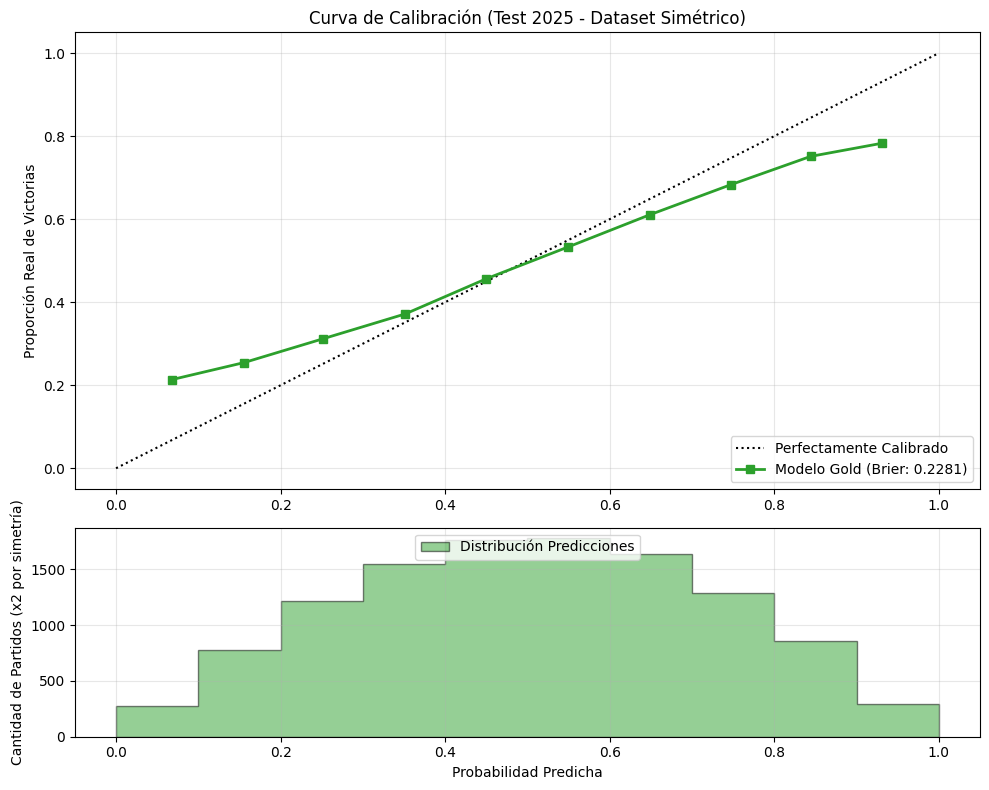

In [ ]:
# Grafica para comprobar si el modelo está bien calibrado
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

print("--- AUDITORÍA FINAL: MODELO 'GOLD TIER' (DATASET YA DUPLICADO) ---")

# 1. PREPARACIÓN DE DATOS (Ventana 2018)
# Como el dataset YA es simétrico, solo filtramos por fecha.
df_partidos['Date'] = pd.to_datetime(df_partidos['Date'])

# Filtro Global: Desde 2002 en adelante
df_modelo = df_partidos[
    (df_partidos['Tier_Numeric'] < 2) &
    (pd.to_datetime(df_partidos['Date']) >= '2002-01-01')
].copy()

# Definir máscaras temporales
# Train: 2018 hasta fin de 2024
mask_train = (df_modelo['Date'] < '2025-01-01')
# Test: 2025 (Futuro)
mask_test = (df_modelo['Date'] >= '2025-01-01')

# Separamos Train y Test
# Al estar ya duplicado, X_train ya tiene A vs B y B vs A.
X_train_full = df_modelo[mask_train]
X_test_full = df_modelo[mask_test]

# 2. DEFINICIÓN DE FEATURES Y TARGET
target = 'playerA_won'
cols_exclude =  [
    'indice', 'Date', 'Tournament', 'player_A', 'player_B', 'Score',
    'playerA_won', 'Total_juegos', 'Numero_sets', 'duracion_min', 'Rd_Ordinal',
    'Diferencia_minutos_acumulados', 'Diferencia_partidos_torneo'
]
# Seleccionamos features numéricas
features = [c for c in X_train_full.columns
            if c not in cols_exclude and X_train_full[c].dtype in [np.float64, np.int64, np.float32]]

X_train = X_train_full[features]
y_train = X_train_full[target]

X_test = X_test_full[features]
y_test = X_test_full[target]

print(f"📊 Dimensiones del Dataset:")
print(f"   Variables (Features): {len(features)}")
print(f"   Filas Train (2018-24): {len(X_train)} (Debe ser par)")
print(f"   Filas Test (2025):     {len(X_test)} (Debe ser par)")

# 3. ENTRENAR MODELO 'GOLD TIER'
params_finales = {
    'subsample': 0.85,
    'colsample_bytree': 0.75,
    'learning_rate': 0.015,
    'max_depth': 7,
    'min_child_weight': 5,
    'n_estimators': 2000,

    # Tus parámetros clave
    'reg_lambda': 15,
    'reg_alpha': 0,
    'gamma': 2,

    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1
}

print("\n🚀 Entrenando XGBoost con configuración 'Gold'...")
clf_final = xgb.XGBClassifier(**params_finales)
clf_final.fit(X_train, y_train)

# 4. PREDICCIONES Y MÉTRICAS
prob_pos = clf_final.predict_proba(X_test)[:, 1]

brier = brier_score_loss(y_test, prob_pos)
ll = log_loss(y_test, prob_pos)
preds_binarias = (prob_pos > 0.5).astype(int)
acc = np.mean(preds_binarias == y_test)

print("\n--- 🏆 RESULTADOS FINALES (TEST 2025 SIMÉTRICO) ---")
print(f"Brier Score: {brier:.5f}")
print(f"Log Loss:    {ll:.4f}")
print(f"Accuracy:    {acc*100:.2f}%")

# 5. GRÁFICO DE CALIBRACIÓN
plt.figure(figsize=(10, 8))
ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)
ax2 = plt.subplot2grid((3, 1), (2, 0))

# Curva
ax1.plot([0, 1], [0, 1], "k:", label="Perfectamente Calibrado")
frac_pos, mean_pred_val = calibration_curve(y_test, prob_pos, n_bins=10)
ax1.plot(mean_pred_val, frac_pos, "s-", label=f"Modelo Gold (Brier: {brier:.4f})", color="#2ca02c", linewidth=2)

ax1.set_ylabel("Proporción Real de Victorias")
ax1.set_title("Curva de Calibración (Test 2025 - Dataset Simétrico)")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Histograma
ax2.hist(prob_pos, range=(0, 1), bins=10, label="Distribución Predicciones",
         histtype="stepfilled", alpha=0.5, color="#2ca02c", edgecolor='black')
ax2.set_xlabel("Probabilidad Predicha")
ax2.set_ylabel("Cantidad de Partidos (x2 por simetría)")
ax2.legend(loc="upper center")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#Calibracion del modelo
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.feature_selection import SelectFromModel

print("--- COMPARATIVA TOTAL: 5 ESTRATEGIAS DE CALIBRACIÓN ---")

# 1. CARGAR DATOS
df_final = df_partidos[
    (df_partidos['Tier_Numeric'] < 2) &
    (pd.to_datetime(df_partidos['Date']) >= '2002-01-01')
].copy()

# Limpieza
cols_borrar = [
    'indice', 'Date', 'Tournament', 'player_A', 'player_B', 'Score',
    'playerA_won', 'Total_juegos', 'Numero_sets', 'duracion_min', 'Rd_Ordinal',
    'Diferencia_minutos_acumulados', 'Diferencia_partidos_torneo'
]

X = df_final.drop(columns=cols_borrar, errors='ignore')
y = df_final['playerA_won']
fechas = pd.to_datetime(df_final['Date'])

# DEFINICIÓN DE SETS
# 1. Para modelos que necesitan calibración externa (Base + Calib)
mask_base = (fechas < '2024-01-01') & ~((fechas >= '2020-01-01') & (fechas < '2022-01-01'))
mask_calib = (fechas >= '2024-01-01') & (fechas < '2025-01-01')

# 2. Para modelos "Full Learning" (Crudo y Ensemble)
mask_full_train = (fechas < '2025-01-01') & ~((fechas >= '2020-01-01') & (fechas < '2022-01-01'))

# 3. Test Común
mask_test = fechas >= '2025-01-01'

# SELECCIÓN DE VARIABLES (Usando Full para ser justos)
clf_sel = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42)
clf_sel.fit(X[mask_full_train], y[mask_full_train])
selector = SelectFromModel(clf_sel, threshold='0.2*mean', prefit=True)

# Transformar sets
X_base_red = selector.transform(X[mask_base])
X_calib_red = selector.transform(X[mask_calib])
X_full_red = selector.transform(X[mask_full_train])
X_test_red = selector.transform(X[mask_test])

y_base = y[mask_base]
y_calib = y[mask_calib]
y_full = y[mask_full_train]
y_test = y[mask_test]

# PARÁMETROS DIAMOND
params = {
    'subsample': 0.85,
    'colsample_bytree': 0.75,
    'learning_rate': 0.015,
    'max_depth': 7,
    'min_child_weight': 5,
    'n_estimators': 2000,

    # Tus parámetros clave
    'reg_lambda': 15,
    'reg_alpha': 0,
    'gamma': 2,

    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_jobs': -1
}

# --- ENTRENAMIENTO ---

print("1. Entrenando Modelo CRUDO (Full)...")
clf_raw = xgb.XGBClassifier(**params, random_state=42)
clf_raw.fit(X_full_red, y_full)
p_raw = clf_raw.predict_proba(X_test_red)[:, 1]

print("2. Entrenando ENSEMBLE (5 modelos Full)...")
probs_ens = np.zeros(len(y_test))
for seed in [42, 43, 44, 45, 46]:
    params['random_state'] = seed
    c = xgb.XGBClassifier(**params)
    c.fit(X_full_red, y_full)
    probs_ens += c.predict_proba(X_test_red)[:, 1]
p_ensemble = probs_ens / 5

print("3. Entrenando BASE para Calibradores...")
params['random_state'] = 42
clf_base = xgb.XGBClassifier(**params)
clf_base.fit(X_base_red, y_base)

print("   -> Ajustando SIGMOIDE...")
cal_sig = CalibratedClassifierCV(clf_base, cv='prefit', method='sigmoid')
cal_sig.fit(X_calib_red, y_calib)
p_sig = cal_sig.predict_proba(X_test_red)[:, 1]

print("   -> Ajustando ISOTÓNICA...")
cal_iso = CalibratedClassifierCV(clf_base, cv='prefit', method='isotonic')
cal_iso.fit(X_calib_red, y_calib)
p_iso = cal_iso.predict_proba(X_test_red)[:, 1]

print("   -> Ajustando BETA CALIBRATION...")
# Clase Beta Manual
class BetaCal:
    def __init__(self): self.lr = LogisticRegression(C=999999999)
    def fit(self, p, y):
        p = np.clip(p, 1e-6, 1-1e-6)
        X_b = np.column_stack([np.log(p), -np.log(1-p)])
        self.lr.fit(X_b, y)
    def predict(self, p):
        p = np.clip(p, 1e-6, 1-1e-6)
        X_b = np.column_stack([np.log(p), -np.log(1-p)])
        return self.lr.predict_proba(X_b)[:, 1]

# Obtenemos probs base en calib y test
p_base_calib = clf_base.predict_proba(X_calib_red)[:, 1]
p_base_test = clf_base.predict_proba(X_test_red)[:, 1]

beta = BetaCal()
beta.fit(p_base_calib, y_calib)
p_beta = beta.predict(p_base_test)

# --- FUNCIÓN DE REPORTE ---
def reporte(nombre, probs, y_true):
    brier = brier_score_loss(y_true, probs)

    df = pd.DataFrame({'y': y_true, 'p': probs})
    bins = np.arange(0, 1.05, 0.05)
    df['bin'] = pd.cut(df['p'], bins=bins)

    tab = df.groupby('bin', observed=False).agg(N=('p','count'), Mean=('p','mean'), Real=('y','mean'))
    tab['Diff'] = tab['Mean'] - tab['Real']

    total = tab['N'].sum()
    ece = (tab['N'] / total * tab['Diff'].abs()).sum()

    print(f"\n📊 {nombre.upper()} (Brier: {brier:.5f} | ECE: {ece:.2%})")
    print("-" * 70)
    print(f"{'Rango':<12} | {'N':<5} | {'Pred':<6} | {'Real':<6} | {'Diff':<6} | {'Estado'}")
    print("-" * 70)

    # Detectar zona densa (bins con > 10% de los datos)
    umbral_densidad = total * 0.10

    for i, r in tab.iterrows():
        if r['N'] > 0:
            mark = ""
            if r['N'] > umbral_densidad: mark = "🔥 ZONA DENSA"

            alerta = ""
            if abs(r['Diff']) > 0.05: alerta = "⚠️"

            print(f"{str(i):<12} | {int(r['N']):<5} | {r['Mean']:.1%}  | {r['Real']:.1%}  | {r['Diff']:+.1%} {alerta} {mark}")

# --- IMPRIMIR RESULTADOS ---
reporte("Diamante Crudo", p_raw, y_test)
reporte("Ensemble (5)", p_ensemble, y_test)
reporte("Isotónica", p_iso, y_test)
reporte("Sigmoide", p_sig, y_test)
reporte("Beta Calib", p_beta, y_test)

--- COMPARATIVA TOTAL: 5 ESTRATEGIAS DE CALIBRACIÓN ---


C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


1. Entrenando Modelo CRUDO (Full)...
2. Entrenando ENSEMBLE (5 modelos Full)...
3. Entrenando BASE para Calibradores...
   -> Ajustando SIGMOIDE...
   -> Ajustando ISOTÓNICA...


C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


   -> Ajustando BETA CALIBRATION...

📊 DIAMANTE CRUDO (Brier: 0.23099 | ECE: 6.54%)
----------------------------------------------------------------------
Rango        | N     | Pred   | Real   | Diff   | Estado
----------------------------------------------------------------------
(0.0, 0.05]  | 74    | 3.8%  | 9.5%  | -5.7% ⚠️ 
(0.05, 0.1]  | 253   | 7.6%  | 22.1%  | -14.5% ⚠️ 
(0.1, 0.15]  | 421   | 12.7%  | 25.4%  | -12.7% ⚠️ 
(0.15, 0.2]  | 485   | 17.6%  | 28.5%  | -10.8% ⚠️ 
(0.2, 0.25]  | 631   | 22.6%  | 29.6%  | -7.0% ⚠️ 
(0.25, 0.3]  | 650   | 27.6%  | 34.5%  | -6.9% ⚠️ 
(0.3, 0.35]  | 776   | 32.6%  | 36.7%  | -4.2%  
(0.35, 0.4]  | 824   | 37.5%  | 41.4%  | -3.9%  
(0.4, 0.45]  | 765   | 42.5%  | 46.7%  | -4.2%  
(0.45, 0.5]  | 766   | 47.4%  | 49.3%  | -1.9%  
(0.5, 0.55]  | 758   | 52.4%  | 49.2%  | +3.2%  
(0.55, 0.6]  | 791   | 57.6%  | 54.5%  | +3.1%  
(0.6, 0.65]  | 781   | 62.4%  | 59.2%  | +3.3%  
(0.65, 0.7]  | 773   | 67.4%  | 60.7%  | +6.8% ⚠️ 
(0.7, 0.75]  | 69

In [ ]:
# Generar un archivo csv con las probabilidades predichas de cada modelo para el calculo del ROI de manera externa
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import SelectFromModel

print("--- GENERANDO DATOS PARA CÁLCULO DE RENTABILIDAD (BACKTESTING 2025) ---")

# 1. CARGAR Y PREPARAR DATOS (2015+)
df_final = df_partidos[
    (df_partidos['Tier_Numeric'] >= 2) &
    (pd.to_datetime(df_partidos['Date']) >= '2018-01-01')
].copy()

# Limpieza
cols_borrar = cols_exclude =  [
    'indice', 'Date', 'Tournament', 'player_A', 'player_B', 'Score',
    'playerA_won', 'Total_juegos', 'Numero_sets', 'duracion_min', 'Rd_Ordinal',
    'Diferencia_minutos_acumulados', 'Diferencia_partidos_torneo'
]

X = df_final.drop(columns=cols_borrar, errors='ignore')
y = df_final['playerA_won']
fechas = pd.to_datetime(df_final['Date'])

# DEFINICIÓN DE SETS
# Para modelos calibrados:
mask_base = (fechas < '2024-01-01') & ~((fechas >= '2020-01-01') & (fechas < '2022-01-01'))
mask_calib = (fechas >= '2024-01-01') & (fechas < '2025-01-01')
# Para modelos full (Crudo/Ensemble):
mask_full = (fechas < '2025-01-01') & ~((fechas >= '2020-01-01') & (fechas < '2022-01-01'))
# Test (Donde calcularemos el dinero):
mask_test = fechas >= '2025-01-01'

# Selección de Variables (VIP)
print("1. Seleccionando variables VIP...")
clf_sel = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42)
clf_sel.fit(X[mask_full], y[mask_full])
selector = SelectFromModel(clf_sel, threshold='0.2*mean', prefit=True)

# Transformar todos los sets
X_base_red = selector.transform(X[mask_base])
X_calib_red = selector.transform(X[mask_calib])
X_full_red = selector.transform(X[mask_full])
X_test_red = selector.transform(X[mask_test])

y_base = y[mask_base]
y_calib = y[mask_calib]
y_full = y[mask_full]

# --- ENTRENAMIENTO DE LOS 4 CONTENDIENTES ---

params = {
    'subsample': 0.85,
    'colsample_bytree': 0.65,
    'learning_rate': 0.02,
    'max_depth': 5,
    'min_child_weight': 10,
    'n_estimators': 1200,

    # Tus parámetros clave
    'reg_lambda': 10,
    'reg_alpha': 5,
    'gamma': 2,

    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_jobs': -1
}

# 1. MODELO DIAMANTE CRUDO (Full Learning)
print("2. Generando predicciones: Diamante Crudo...")
clf_raw = xgb.XGBClassifier(**params, random_state=42)
clf_raw.fit(X_full_red, y_full)
probs_raw = clf_raw.predict_proba(X_test_red)[:, 1]

# 2. MODELO ENSEMBLE (5 Semillas)
print("3. Generando predicciones: Ensemble (5)...")
probs_ens = np.zeros(len(X_test_red))
for seed in [42, 43, 44, 45, 46]:
    params['random_state'] = seed
    c = xgb.XGBClassifier(**params)
    c.fit(X_full_red, y_full)
    probs_ens += c.predict_proba(X_test_red)[:, 1]
probs_ensemble = probs_ens / 5

# 3. MODELOS CALIBRADOS (Base + 2024)
print("4. Generando predicciones: Calibrados (Iso/Sig)...")
params['random_state'] = 42
clf_base = xgb.XGBClassifier(**params)
clf_base.fit(X_base_red, y_base)

# Sigmoide
cal_sig = CalibratedClassifierCV(clf_base, cv='prefit', method='sigmoid')
cal_sig.fit(X_calib_red, y_calib)
probs_sig = cal_sig.predict_proba(X_test_red)[:, 1]

# Isotónica
cal_iso = CalibratedClassifierCV(clf_base, cv='prefit', method='isotonic')
cal_iso.fit(X_calib_red, y_calib)
probs_iso = cal_iso.predict_proba(X_test_red)[:, 1]

# --- CONSTRUCCIÓN DEL DATAFRAME MAESTRO ---
print("5. Construyendo Excel de Rentabilidad...")

# Recuperamos metadatos del Test Set
df_test_meta = df_final[mask_test][['Date', 'Tournament', 'Rd_Ordinal', 'player_A', 'player_B', 'playerA_won']].copy()

# Añadimos las probabilidades
df_test_meta['Prob_Crudo'] = probs_raw
df_test_meta['Prob_Ensemble'] = probs_ensemble
df_test_meta['Prob_Sigmoide'] = probs_sig
df_test_meta['Prob_Isotonica'] = probs_iso

# Ganador real (Texto) para facilitar lectura
df_test_meta['Ganador_Real'] = df_test_meta.apply(lambda x: x['player_A'] if x['playerA_won'] == 1 else x['player_B'], axis=1)

# Reordenar columnas
cols_orden = [
    'Date', 'Tournament', 'Rd_Ordinal',
    'player_A', 'player_B', 'Ganador_Real', 'playerA_won',
    'Prob_Crudo', 'Prob_Ensemble', 'Prob_Isotonica', 'Prob_Sigmoide'
]
df_export = df_test_meta[cols_orden]

# Guardar
archivo = 'analisis_rentabilidad_2025.csv'
df_export.to_csv("/Users/UJA/Desktop/Datos/analisis_rentabilidad_2025.csv", index=False)

--- GENERANDO DATOS PARA CÁLCULO DE RENTABILIDAD (BACKTESTING 2025) ---
1. Seleccionando variables VIP...
2. Generando predicciones: Diamante Crudo...
3. Generando predicciones: Ensemble (5)...
4. Generando predicciones: Calibrados (Iso/Sig)...
5. Construyendo Excel de Rentabilidad...


**El modelo con el mejor ROI es la beta calibracion**

--- 🚀 ENTRENAMIENTO FINAL: DIAMANTE BETA-CALIBRADO (2026 Ready) ---
2. Filtrando variables maestras...


C:\Users\UJA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Variables Seleccionadas: 99
3. Entrenando Cerebro Base (XGBoost)...
4. Ajustando Calibrador Beta con datos 2024-2025...
✅ Sistema Beta-Calibrado guardado en 'IA_Tenis_Beta_2026'.

--- 🧠 RADIOGRAFÍA DEL MODELO ---


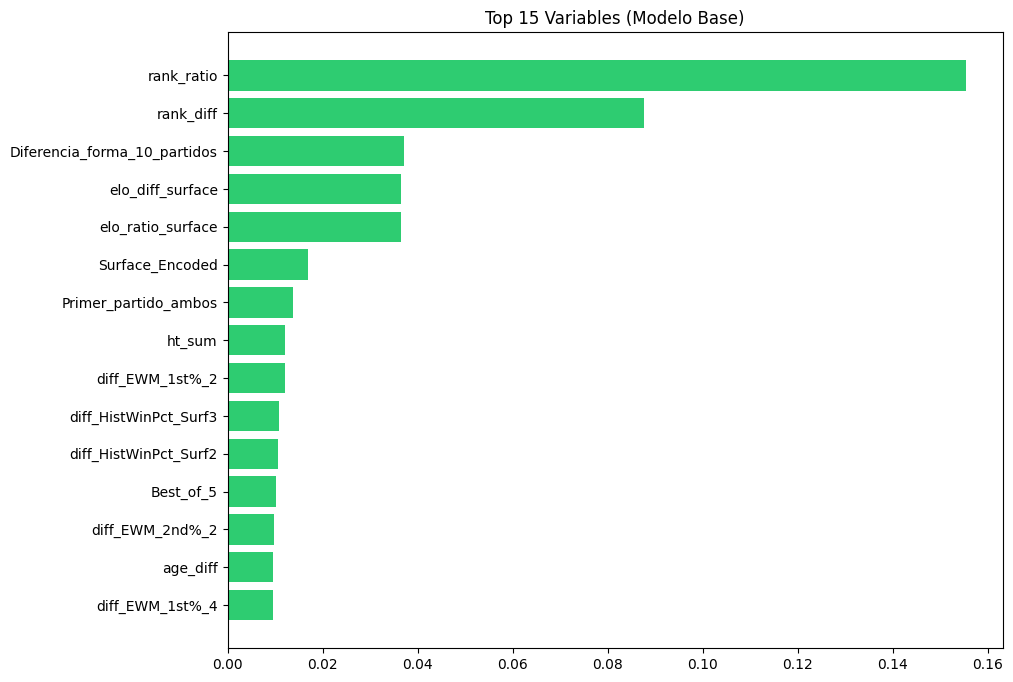

Calculando SHAP Values...


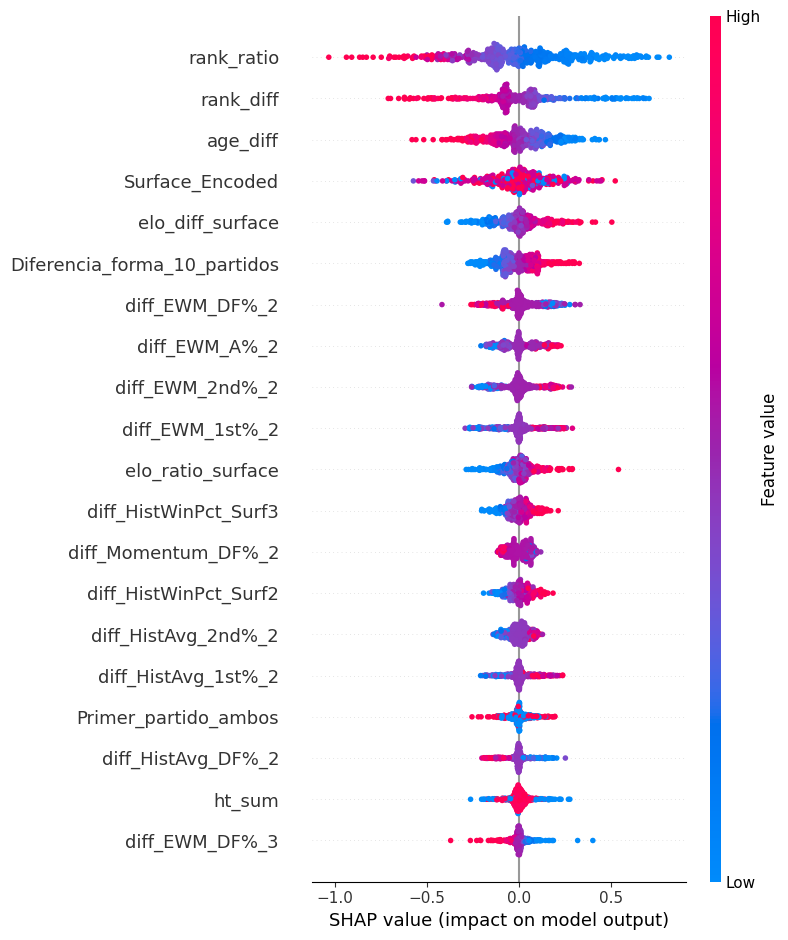

In [6]:
#Entrenamiento del modelo final  con todos los datos + importancia variables y funcionamiento modelo

import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import os
import matplotlib.pyplot as plt
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

print("--- 🚀 ENTRENAMIENTO FINAL: DIAMANTE BETA-CALIBRADO (2026 Ready) ---")

# 1. CARGA Y PREPARACIÓN DE DATOS (Añadimos .reset_index)
df_final = df_partidos[
    (df_partidos['Tier_Numeric'] < 2) &
    (pd.to_datetime(df_partidos['Date']) >= '2002-01-01')
].copy()

# --- IMPORTANTE: Resetear índice aquí para que todo coincida ---
df_final = df_final.reset_index(drop=True)

cols_borrar = [
    'indice', 'Date', 'Tournament', 'player_A', 'player_B', 'Score',
    'playerA_won', 'Total_juegos', 'Numero_sets', 'duracion_min', 'Rd_Ordinal',
    'Diferencia_minutos_acumulados', 'Diferencia_partidos_torneo'
]

fechas = pd.to_datetime(df_final['Date'])
mask_valid = ~((fechas >= '2020-01-01') & (fechas < '2022-01-01'))

# Aplicamos la máscara de validez y reseteamos de nuevo para seguridad absoluta
X_raw = df_final.drop(columns=cols_borrar, errors='ignore')[mask_valid].reset_index(drop=True)
y_all = df_final['playerA_won'][mask_valid].reset_index(drop=True)
fechas_valid = fechas[mask_valid].reset_index(drop=True)

# 2. DEFINICIÓN DE SETS PARA CALIBRACIÓN
# Ahora las máscaras tendrán índices 0, 1, 2... igual que X_selected
mask_train_base = (fechas_valid < '2024-01-01')
mask_train_beta = (fechas_valid >= '2024-01-01')

# 3. SELECCIÓN DE VARIABLES (VIP)
print("2. Filtrando variables maestras...")
clf_sel = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42)
clf_sel.fit(X_raw[mask_train_base], y_all[mask_train_base])

# Para evitar el Warning de "feature names", usamos los nombres de X_raw
selector = SelectFromModel(clf_sel, threshold='0.2*mean', prefit=True)
feature_names = X_raw.columns[selector.get_support()].tolist()

# Transformamos y mantenemos el índice coherente
X_selected = pd.DataFrame(
    selector.transform(X_raw),
    columns=feature_names,
    index=X_raw.index # Esto asegura que el índice sea el mismo
)

print(f"Variables Seleccionadas: {len(feature_names)}")

# 4. CLASE BETA CALIBRATION
class BetaCalibrator:
    def __init__(self):
        self.lr = LogisticRegression(C=1e6, solver='lbfgs')

    def fit(self, p, y):
        # Transformación Beta: log(p) y -log(1-p)
        p = np.clip(p, 1e-6, 1-1e-6)
        X_beta = np.column_stack([np.log(p), -np.log(1-p)])
        self.lr.fit(X_beta, y)
        return self

    def predict(self, p):
        p = np.clip(p, 1e-6, 1-1e-6)
        X_beta = np.column_stack([np.log(p), -np.log(1-p)])
        return self.lr.predict_proba(X_beta)[:, 1]

# 5. ENTRENAMIENTO DEL MODELO BASE
carpeta = "IA_Tenis_Beta_2026"
if not os.path.exists(carpeta): os.makedirs(carpeta)

params = {
    'subsample': 0.85, 'colsample_bytree': 0.75, 'learning_rate': 0.015,
    'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 2000,
    'reg_lambda': 15, 'reg_alpha': 0, 'gamma': 2,
    'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_jobs': -1,
    'random_state': 42
}

print("3. Entrenando Cerebro Base (XGBoost)...")
model_base = xgb.XGBClassifier(**params)
model_base.fit(X_selected[mask_train_base], y_all[mask_train_base])

# 6. ENTRENAMIENTO DEL CALIBRADOR BETA
print("4. Ajustando Calibrador Beta con datos 2024-2025...")
p_base_calib = model_base.predict_proba(X_selected[mask_train_beta])[:, 1]
beta_cal = BetaCalibrator()
beta_cal.fit(p_base_calib, y_all[mask_train_beta])

# 7. GUARDAR TODO EL SISTEMA
joblib.dump(feature_names, os.path.join(carpeta, "features_vip.pkl"))
joblib.dump(model_base, os.path.join(carpeta, "modelo_base.pkl"))
joblib.dump(beta_cal, os.path.join(carpeta, "calibrador_beta.pkl"))
print(f"✅ Sistema Beta-Calibrado guardado en '{carpeta}'.")

# ==============================================================================
# 8. RADIOGRAFÍA Y EXPLICABILIDAD
# ==============================================================================
print("\n--- 🧠 RADIOGRAFÍA DEL MODELO ---")

# Importancia de Variables
importances = model_base.feature_importances_
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 8))
plt.title('Top 15 Variables (Modelo Base)')
plt.barh(range(len(indices)), importances[indices], color='#2ecc71', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.show()

# SHAP Values
print("Calculando SHAP Values...")
X_sample = X_selected[mask_train_beta].sample(min(500, len(X_selected[mask_train_beta])), random_state=42)
explainer = shap.TreeExplainer(model_base)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample)